In [4]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split

# File system manangement
import os

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns




# from sklearnex import patch_sklearn
# patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()



# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src.config import Config as Config  
from src.data_loader import load_data, prepare_data

cfg = Config

KAGGLE_EVAL = cfg.KAGGLE_EVAL
RANDOM_STATE = cfg.RANDOM_STATE
TASK = cfg.TASK
USE_POSTPROCESSING = cfg.USE_POSTPROCESSING
TARGET = cfg.TARGET
ID = cfg.ID
SUB_PATH = cfg.SUB_PATH
SUBMIT_PROBABILITIES = cfg.SUBMIT_PROBABILITIES
metric_name = cfg.LIB_PARAMS["lightgbm"]["metric"]

# -------------------------------------------------------



# this notebook
from src.optuna_utils import run_optuna
from src.evaluation_utils import evaluate_model, evaluate_metric
from src.visualization_utils import (
    plot_feature_importance,
    plot_learning_curve,
    shap_summary
)
from sklearn.metrics import accuracy_score,roc_auc_score, log_loss

from src.postprocessing_utils import optimize_postprocessing, apply_postprocessing


import catboost as cb
import optuna
import time
import gc
import optuna.visualization as vis
from sklearn.utils.class_weight import compute_class_weight


# -------------------------------
# Load Data
# -------------------------------
X_train, X_test, y_train, y_test = load_data("encoded")
# Prepare
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True # ,label_map = {"A": 1, "B": 0, "C": 2}
)

# Ensure y is numpy array
y_train_numeric = np.array(y_train_numeric)
y_test_numeric = np.array(y_test_numeric) if y_test_numeric is not None else None

sys.path contains: /home/ismail/x42
Number of classes: 2
X_train shape: (300000, 116)
X_test shape: (200000, 116)
y_train shape: (300000,)
y_test labels are not available


In [5]:

from sklearn.model_selection import train_test_split


X_train, _, y_train_numeric, _ = train_test_split(
    X_train,
    y_train_numeric,
    test_size=0.95,              # keep only 10%
    random_state=RANDOM_STATE,
    stratify=y_train_numeric    # IMPORTANT: preserves class balance
)

print("Original:", X_train.shape)
print("Sample:", X_train.shape)

X_test = X_test.sample(
    frac=0.07,
    random_state=RANDOM_STATE
)

Original: (15000, 116)
Sample: (15000, 116)


In [6]:
# -------------------------------
# Data splitter
# -------------------------------
from src.data_splitter import DataSplitter


splitter = DataSplitter(
    method="stratified_kfold",
    n_splits=5,
    random_state=RANDOM_STATE,
    folds_path="data/folds.npy"
)
folds = list(splitter.split(X_train, y_train_numeric, reuse_folds=True, verbose=True))

✅ Loaded 5 folds from data/folds.npy
♻️ Reusing existing folds
--- Splitting data ---
Method: stratified_kfold
Number of splits: 5
Random seeds: [42]
Dataset size: 15000
Total folds: 5

Fold 0: Train size=12000, Val size=3000
Fold 1: Train size=12000, Val size=3000
Fold 2: Train size=12000, Val size=3000
Fold 3: Train size=12000, Val size=3000
Fold 4: Train size=12000, Val size=3000


In [ ]:
# cols_to_drop = bottom_10_df['feature'].tolist()
# X_train = X_train.drop(columns=cols_to_drop)
# X_test = X_test.drop(columns=cols_to_drop)

**Include in cat_features**

- String/Text Labels: "New York", "Red", "High".
- Boolean Flags: True/False, 1/0 (if they represent categories).
- Integer-encoded Categories: Store IDs (101, 102) where 102 isn't "greater" than 101.
- Low-Cardinality Ordinal Text: "Small", "Medium", "Large".
**Exclude from cat_features**
- Continuous Numbers: Age, Salary, Temperature.
- High-Cardinality Unique IDs: Row_ID or Timestamp (usually drop these entirely).
- Ranked Numerics: "Star Rating" (1-5) can often stay numerical so the model understands 5 > 4.
- Date Components: Year/Month/Day (usually better as numerical).

In [29]:
# Initialize as empty list to prevent errors
cat_features = []

# Automatically detect based on data type
# We include 'object', 'category', and 'bool' (CatBoost handles bools well as categories)

# cat_features = list(X_train.select_dtypes(include=['object', 'category', 'bool']).columns) # use  this

# Manual addition/removal
# Use this if you have integer-encoded categories (e.g., 'Store_ID' or 'Region_Code')
# manual_cats = ['Region_ID', 'Department_Code']
# cat_features = list(set(cat_features + manual_cats))

# Ensure they exist in the current X_train (safety check)
# cat_features = [col for col in cat_features if col in X_train.columns] # use this

print(f"Final cat_features list ({len(cat_features)}): {cat_features}")

Final cat_features list (0): []



**Replace NaN with a string and ensure string dtype**

In [30]:



# for col in cat_features:
#     X_train[col] = X_train[col].fillna('__MISSING__').astype(str)
#     X_test[col]  = X_test[col].fillna('__MISSING__').astype(str)


# cat_idx = [X_train.columns.get_loc(col) for col in cat_features]

# # Convert cat_features to pd.Categorical dtype
# for col in cat_features:
#     X_train[col] = pd.Categorical(X_train[col])
#     X_test[col] = pd.Categorical(X_test[col])

**Params tuning stratigy:**
- Set iterations to a fixed, moderate value: Don't start with 5,000. Start with 500–1000 during Optuna trials to see which parameters react well.
- Use task_type='GPU': If you have a GPU, CatBoost is significantly faster (often 10x-40x) than on CPU.
- Lower border_count: Default is 254. Setting this to 32 or 64 during tuning speeds up the preprocessing and tree building significantly with minimal impact on initial ranking.
- Limit depth: Search between 4 and 8 initially. Depths of 10+ exponentially slow down training.

Once you have the speed setup, focus your Optuna search on these "Big Three" parameters:

- learning_rate: This is your most important parameter. If you use a high learning rate, you need fewer iterations (faster). If you use a low learning rate, you need more iterations (more accurate).
- l2_leaf_reg: This is the primary L2 regularization. It is very effective at stopping overfitting on noisy tabular data.
- random_strength: This adds randomness to the scores when selecting splits. It's a "secret weapon" for preventing the model from becoming too greedy.


<mark>Dealing with Overfitting: od_type</mark>

CatBoost has a built-in "Overfitting Detector."

- od_type='Iter': Stops training if the metric hasn't improved for od_wait iterations.

- od_type='IncToDec': A more complex detector based on the derivative of the loss curve.



Note: If you use Lossguide, you must also tune max_leaves, as depth alone won't control the complexity.


**Feature Interactions (max_ctr_complexity)**

CatBoost is unique because it automatically creates feature interactions (e.g., City + Gender).
- By default, it looks at pairs. If you suspect three-way interactions are important, set max_ctr_complexity=3.

**Feature Importance Methods**

- PredictionValuesChange: Standard (how much the prediction changes on average).
- LossFunctionChange: Usually more accurate for determining which features actually help the model generalize.
- ShapValues: Use this for the most robust, theoretically sound interpretation.



In [55]:


num_classes = len(np.unique(y_train_numeric))
print(f"Number of classes: {num_classes}")

# -------------------------------
# Optuna objective function
# -------------------------------
def objective(trial):
    # ------------------------------------
    # CatBoost implementation
    # -----------------------------------------

    iterations = 500 # start with 500/1000 final 5000
    max_depth = trial.suggest_int("depth", 3, 8) # use 8 instead of 12. Depths of 10+ exponentially slow down training.

    param = {
        'loss_function': cfg.LIB_PARAMS["catboost"]["loss_function"], # e.g., 'Logloss' or 'MultiClass'
        'eval_metric': cfg.LIB_PARAMS["catboost"]["eval_metric"], # e.g., 'AUC' or 'Logloss'
        
        'iterations': iterations,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'depth': max_depth,
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 64), # 255
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),

        'bootstrap_type': 'MVS',
        # 'grow_policy': Lossguide: Similar to LightGBM; can lead to higher accuracy but overfits more easily. / Depthwise: Similar to XGBoost.
        # 'model_shrink_rate': For very long training sessions, shrinking the model size can help with inference speed.
        
        'random_seed': getattr(cfg, "RANDOM_STATE", 42),
        'verbose': False,
        'allow_writing_files': False,
        'task_type': 'CPU', # CPU or 'GPU'

                # Overfitting control
        # 'od_type': 'Iter',
        # 'od_wait': 100,
    }

    # -------------------------------
    # Determine if metric is maximize or minimize
    # -------------------------------
    metric_name = cfg.LIB_PARAMS["catboost"]["eval_metric"]
    maximize_metric = cfg.MAXIMIZE_METRIC

    if num_classes > 2:
        param['classes_count'] = num_classes

    # -------------------------------
    # Dataset creation with class weights
    # -------------------------------
    if cfg.TASK.lower() == "multiclass":
        classes = np.unique(y_train_numeric)
        class_weights = compute_class_weight("balanced", classes=classes, y=y_train_numeric)
        param['class_weights'] = class_weights.tolist()
        oof_preds = np.zeros((len(X_train), num_classes))
    elif cfg.TASK.lower() == "binary":
        if getattr(cfg, "IS_UNBALANCE", True):
            # CatBoost equivalent of is_unbalance is auto_class_weights
            param['auto_class_weights'] = 'Balanced'
        oof_preds = np.zeros(len(X_train))

    fold_results = []
    all_fold_evals = []

    for n_fold, (train_idx, valid_idx) in enumerate(folds, start=1):

        X_tr, y_tr = X_train.iloc[train_idx], y_train_numeric[train_idx]
        X_val, y_val = X_train.iloc[valid_idx], y_train_numeric[valid_idx]


        train_pool = cb.Pool(X_tr, y_tr, cat_features=cat_features)
        valid_pool = cb.Pool(X_val, y_val, cat_features=cat_features)


        model = cb.CatBoostClassifier(**param)

        model.fit(
            train_pool,
            eval_set=valid_pool,
            early_stopping_rounds=100,
            use_best_model=True,
            verbose=False
        )
        
        # Store eval results for the learning curve
        evals_result = model.get_evals_result()
        all_fold_evals.append(evals_result)
        
        # -------------------------------
        # Predictions for OOF
        # -------------------------------
        # prediction_type='Probability' for log_loss/AUC
        pred_val = model.predict_proba(X_val)
        
        if cfg.TASK.lower() == "binary":
            oof_preds[valid_idx] = pred_val[:, 1]
            current_pred = pred_val[:, 1]
        else:
            oof_preds[valid_idx] = pred_val
            current_pred = pred_val

        # -------------------------------
        # Evaluate fold
        # -------------------------------
        if maximize_metric: 
            if cfg.TASK.lower() == "binary":
                fold_score = roc_auc_score(y_val, current_pred)
            else:
                fold_score = roc_auc_score(y_val, current_pred, multi_class="ovr")
        else:
            fold_score = log_loss(y_val, current_pred)

        fold_results.append((n_fold, fold_score, model.get_best_iteration()))
        trial.report(fold_score, step=n_fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

        del model, train_pool, valid_pool, X_tr, X_val, y_tr, y_val
        if len(X_train) > getattr(cfg, "LARGE_DATASET_THRESHOLD", 500_000):
            gc.collect()
    
    gc.collect()

    # -------------------------------
    # True OOF score
    # -------------------------------
    if maximize_metric:
        if cfg.TASK.lower() == "binary":
            mean_score = roc_auc_score(y_train_numeric, oof_preds)
        else:
            mean_score = roc_auc_score(y_train_numeric, oof_preds, multi_class="ovr")
        # Extract best iteration based on metric
        best_iter = int(np.round(np.mean([f['validation'][metric_name].index(max(f['validation'][metric_name])) for f in all_fold_evals])))
    else:
        mean_score = log_loss(y_train_numeric, oof_preds)
        best_iter = int(np.round(np.mean([f['validation'][metric_name].index(min(f['validation'][metric_name])) for f in all_fold_evals])))

    # -------------------------------
    # Fold report
    # -------------------------------
    metric_label = "AUC" if maximize_metric else "LogLoss"
    print("\n" + "*"*50)
    for fold, score, iter_ in fold_results:
        print(f"Fold {fold:>2d} | {metric_label}: {score:.5f} | Best iteration: {iter_:>5d}")

    std_score = np.std([s for _, s, _ in fold_results])
    print(f"\nMean {metric_label}: {mean_score:.5f} ± {std_score:.5f}")
    print("*"*50 + "\n")

    # -------------------------------
    # Store trial info
    # -------------------------------
    trial.set_user_attr("fold_evals", all_fold_evals)
    trial.set_user_attr("best_iteration", best_iter)
    trial.set_user_attr("mean_score", mean_score)
    trial.set_user_attr("params", param)
    trial.set_user_attr("oof_preds", oof_preds)

    return mean_score


Number of classes: 2


In [56]:

# -------------------------------
# Execution Block
# -------------------------------
start = time.time()
study = run_optuna(objective, cfg, use_median_pruner=True, warmup_steps=2)
train_time = time.time() - start

fold_evals = study.best_trial.user_attrs['fold_evals']
oof_preds = study.best_trial.user_attrs['oof_preds']

# -------------------------------
# Train final CatBoost model
# -------------------------------
best_params = study.best_params.copy()
# Map Optuna suggestion names back to CatBoost expected names if different
best_params.update({
    'loss_function': cfg.LIB_PARAMS["catboost"]["loss_function"],
    'eval_metric': 'AUC' if metric_name.upper() else metric_name,
    'verbose': False,
    'allow_writing_files': False
})
if cfg.TASK.lower() == "multiclass":
    best_params['classes_count'] = num_classes
    classes = np.unique(y_train_numeric)
    class_weights = compute_class_weight("balanced", classes=classes, y=y_train_numeric)
    best_params['class_weights'] = class_weights.tolist()
elif cfg.TASK.lower() == "binary":
    if getattr(cfg, "IS_UNBALANCE", True):
        best_params['auto_class_weights'] = 'Balanced'

best_iteration = study.best_trial.user_attrs.get("best_iteration", cfg.NUM_BOOST_ROUND)
print("\nTraining final model on full training data...")

# final_model = train_catboost_final(...) logic
final_model = cb.CatBoostClassifier(**best_params, iterations=best_iteration)
final_model.fit(X_train, y_train_numeric, cat_features=cat_features, verbose=False)

# -------------------------------
# Evaluate on train set
# -------------------------------
print("---------------- Train Set --------------------")
# CatBoost predict_proba returns [prob_0, prob_1] for binary
train_preds = final_model.predict_proba(X_train)
if cfg.TASK.lower() == "binary":
    train_preds_input = train_preds[:, 1]
else:
    train_preds_input = train_preds

metrics_df, y_pred_train_class = evaluate_model(y_train_numeric, train_preds_input, task=cfg.TASK)
print(metrics_df)
print("The best mean CV score across all trials :", study.best_value)

if cfg.TASK.lower() == "binary":
    oof_pred_class = (oof_preds >= 0.5).astype(int)
else:  
    oof_pred_class = np.argmax(oof_preds, axis=1)

oof_score = evaluate_metric(
    y_true=y_train_numeric,
    y_input=oof_preds, 
    task=TASK,
    kaggle_eval=KAGGLE_EVAL
)
print(f"OOF {KAGGLE_EVAL}: {oof_score:.5f}")

# -------------------------------
# Evaluate on test set
# -------------------------------
test_preds = final_model.predict_proba(X_test)
if cfg.TASK.lower() == "binary":
    test_preds_input = test_preds[:, 1]
    y_pred_class = (test_preds_input >= 0.5).astype(int)
else:
    test_preds_input = test_preds
    y_pred_class = test_preds.argmax(axis=1)

if X_test is not None and y_test is not None:
    roc_auc_test = roc_auc_score(y_test, test_preds_input) if cfg.TASK=='binary' else roc_auc_score(y_test, test_preds_input, multi_class='ovr')
    logloss_test = log_loss(y_test, test_preds_input)
    accuracy_test = accuracy_score(y_test, y_pred_class)

    print("\n--- Test set performance ---")
    print(f"Test ROC AUC: {roc_auc_test:.5f}")
    print(f"Test Log Loss: {logloss_test:.5f}")
    print(f"Test Accuracy: {accuracy_test:.5f}")






# -------------------------------
# Optional post-processing
# -------------------------------
postprocessing_params = {}
if USE_POSTPROCESSING:
    pp_seeds = [RANDOM_STATE, 2026, 1234, 9999]
    pp_best_params, pp_best_seed, pp_best_score = optimize_postprocessing(
        oof_preds,
        y_train_numeric,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL,
        n_trials=100,
        seeds=pp_seeds
    )

    oof_pred_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK, return_proba=True)
    oof_pred_class_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK)
    oof_acc_opt = evaluate_metric(
        y_true=y_train_numeric,
        y_input=oof_pred_opt,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL
    )

    print(f"OOF {KAGGLE_EVAL} after post-processing: {oof_acc_opt:.5f}")
    postprocessing_params = {
        "best_params": pp_best_params,
        "best_seed": pp_best_seed,
        "best_score": pp_best_score,
        "oof_pred_class_opt": oof_pred_class_opt,
        "oof_pred_opt": oof_pred_opt,
        "oof_acc_opt": oof_acc_opt,
        "kaggle_eval": KAGGLE_EVAL
    }


# -------------------------------
# ExperimentTracker
# -------------------------------
from src.experiment_tracker import ExperimentTracker

tracker = ExperimentTracker()
exp_dir = tracker.run_experiment(
    model_name="catboost",
    final_model=final_model,
    X_train=X_train,
    y_train=y_train_numeric,
    X_test=X_test,
    best_params=best_params,
    best_score=study.best_value,
    metrics_df=metrics_df,
    train_time=train_time,
    oof_preds=oof_preds,
    task=TASK,
    postprocessing_params=postprocessing_params,
    use_postprocessing=USE_POSTPROCESSING,
    test_ids=test_ids,
    id_col=ID,
    target_col=TARGET,
    int_to_label=int_to_label,
    sample_submission_path=SUB_PATH,
    submit_proba=SUBMIT_PROBABILITIES
)

gc.collect()

  0%|          | 0/100 [00:00<?, ?it/s]


**************************************************
Fold  1 | AUC: 0.78490 | Best iteration:   333
Fold  2 | AUC: 0.78653 | Best iteration:   269
Fold  3 | AUC: 0.79178 | Best iteration:   382
Fold  4 | AUC: 0.79318 | Best iteration:   298
Fold  5 | AUC: 0.78010 | Best iteration:   333

Mean AUC: 0.78713 ± 0.00475
**************************************************


**************************************************
Fold  1 | AUC: 0.77619 | Best iteration:   280
Fold  2 | AUC: 0.78493 | Best iteration:   291
Fold  3 | AUC: 0.78593 | Best iteration:   273
Fold  4 | AUC: 0.78507 | Best iteration:   155
Fold  5 | AUC: 0.77718 | Best iteration:   182

Mean AUC: 0.78127 ± 0.00425
**************************************************


**************************************************
Fold  1 | AUC: 0.77913 | Best iteration:   498
Fold  2 | AUC: 0.78618 | Best iteration:   498
Fold  3 | AUC: 0.78919 | Best iteration:   499
Fold  4 | AUC: 0.78827 | Best iteration:   499
Fold  5 | AUC: 0.77732 |

117

In [ ]:
0.79035

If you see a very high score for a specific pair, consider creating a manual interaction feature (e.g., df['feat1_feat2'] = df['feat1'].astype(str) + "_" + df['feat2'].astype(str)) in your next experiment to see if it helps the model converge even faster!

**Data leakaage**
- The Risk: If two features are interacting strongly, ensure that your Target Encoding was done strictly within cross-validation folds.

- The Fix: If you notice your CV score is much higher than your LB (Leaderboard) score, this interaction might be the model "cheating" by picking up on target signals leaked through the encoding.

In [50]:
import pandas as pd

# 1. Create the Pool with the same cat_features used during training
# We use X_train and y_train_numeric to match the model's expected input shape
eval_pool = cb.Pool(X_train, label=y_train_numeric, cat_features=cat_features)

# 2. Calculate Interactions
# 'Interaction' type returns a list of [feature_idx_1, feature_idx_2, score]
interaction_raw = final_model.get_feature_importance(eval_pool, type="Interaction")

# 3. Map indices back to column names
column_names = X_train.columns.values
interaction_data = []

for item in interaction_raw:
    f1 = column_names[int(item[0])]
    f2 = column_names[int(item[1])]
    score = item[2]
    interaction_data.append([f1, f2, score])

# 4. Create and display DataFrame
interaction_df = pd.DataFrame(interaction_data, columns=["feature1", "feature2", "importance"])
interaction_df = interaction_df.sort_values(by="importance", ascending=False)

print("Top 20 Feature Interactions:")
interaction_df.head(20)

Top 20 Feature Interactions:


,feature1,feature2,importance
0,ord_3,nom_9_te_oof,0.846378
1,ord_4,ord_5_oe1,0.774804
2,ord_0,nom_5_catb_enc,0.751748
3,ord_4,nom_9_te_oof,0.675140
4,ord_2,nom_7_te_oof,0.590138
5,le_nom_9,nom_6_catb_enc,0.581173
6,nom_3_te,_hash_enc44,0.580016
7,ord_2,nom_6_te_oof,0.571868
8,nom_5_te_oof,nom_6_te_oof,0.526879
9,ord_4,nom_7_te_oof,0.526677


try this shit for explaining model looks fucking great


In [51]:
import shap

# 1. Use the cat_features indices we defined earlier
# SHAP works best when the Pool has the exact same structure as training
shap_pool = cb.Pool(X_train, label=y_train_numeric, cat_features=cat_features)

# 2. Initialize the Explainer
# CatBoost has a native SHAP implementation that is very fast
explainer = shap.TreeExplainer(final_model)

# 3. Calculate SHAP values
# For multiclass, this returns a list of arrays. For binary, a single array.
shap_values = explainer.shap_values(shap_pool)

# 4. Handle the "slice" for the interactive plot
# If multiclass, we usually plot SHAP values for a specific class (e.g., class 0)
# If binary, shap_values is typically a 2D array already.
if isinstance(shap_values, list):
    # Multiclass case: picking the first class to visualize
    plot_shap = shap_values[0][:200, :]
    expected_val = explainer.expected_value[0]
else:
    # Binary case
    plot_shap = shap_values[:200, :]
    expected_val = explainer.expected_value

# 5. Render the plot
shap.initjs()
shap.force_plot(
    expected_val, 
    plot_shap, 
    X_train.iloc[:200, :]
)

Visualizing explanation for: Class 0


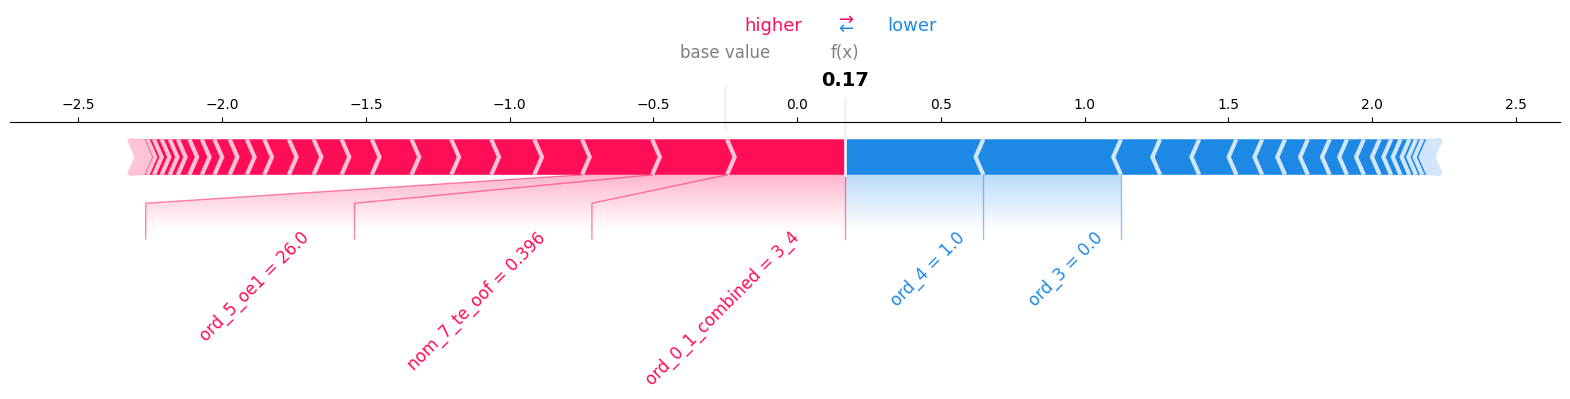

In [52]:
import shap
shap.initjs()

# --- IMPROVEMENT: Handle Multi-Class Labels ---
# If you have a list of class names (e.g., ['Dog', 'Cat', 'Bird']), 
# use it to label the plot so you know WHICH class you are looking at.
class_to_plot = 0 

# Check if int_to_label exists AND is actually a dictionary/list, not None
if 'int_to_label' in locals() and int_to_label is not None:
    class_name = int_to_label[class_to_plot]
else:
    class_name = f"Class {class_to_plot}"

print(f"Visualizing explanation for: {class_name}")


# 1. Define the Pool
shap_pool = cb.Pool(X_train, label=y_train_numeric, cat_features=cat_features)

# 2. Explainer
explainer = shap.TreeExplainer(final_model)

# 3. Calculate values
shap_values = explainer.shap_values(shap_pool)

# 4. Extract logic
if isinstance(shap_values, list):
    # For Multiclass, we MUST index into the list for the specific class
    plot_shap = shap_values[class_to_plot][:200, :]
    expected_val = explainer.expected_value[class_to_plot]
else:
    # For Binary, it's a single array
    plot_shap = shap_values[:200, :]
    expected_val = explainer.expected_value

# 5. The Plot
# We use link='logit' if we want to see probabilities (0 to 1) 
# instead of raw margin scores (log-odds).
# Change the index (e.g., 0) to see a different specific row
row_idx = 0 

shap.force_plot(
    expected_val, 
    plot_shap[row_idx, :], # Single row slice
    X_train.iloc[row_idx, :],
    matplotlib=True, # Using matplotlib renders a static, high-res image
    text_rotation=45 # Rotates labels so they don't overlap
)

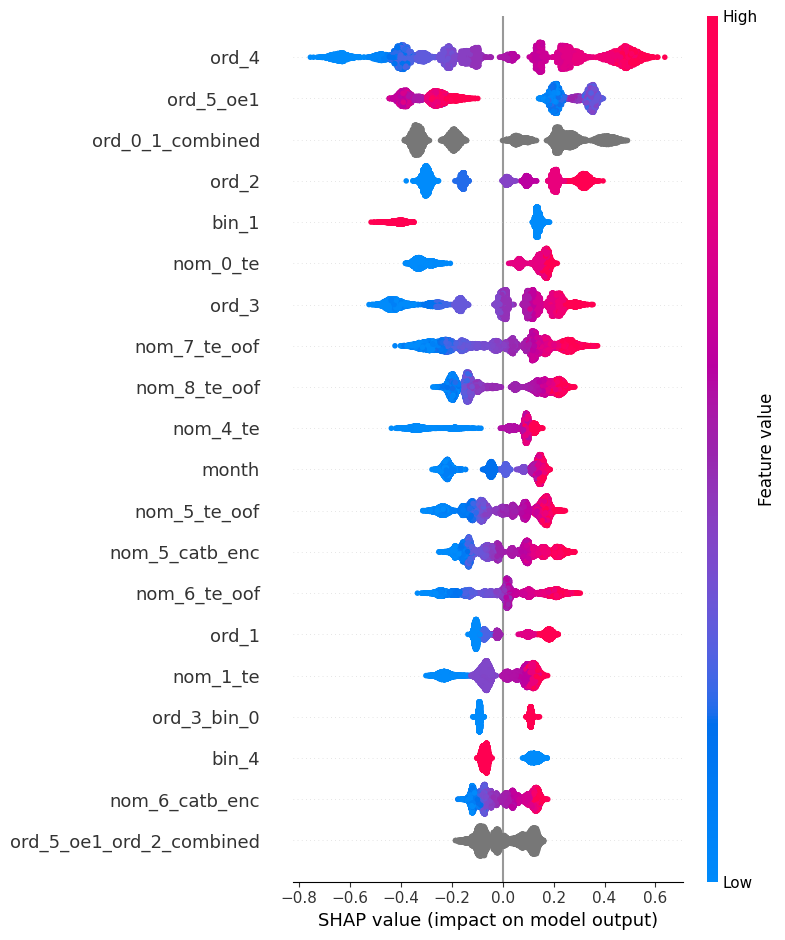

In [53]:
shap.summary_plot(shap_values, X_train, max_display=20)

In [42]:
# 1. Create a Pool (if you haven't already for SHAP)
# It's vital to include cat_features so the model knows how to process the columns
importance_pool = cb.Pool(X_train, label=y_train_numeric, cat_features=cat_features)

# 2. Get feature importance by passing the data argument
# This tells CatBoost: "Calculate how much the loss increases if we remove each feature from THIS data"
feat_importance = final_model.get_feature_importance(
    data=importance_pool, 
    type='LossFunctionChange'
)

# 3. Create the DataFrame and find the bottom 10%
feat_names = X_train.columns
importance_df = pd.DataFrame({
    'feature': feat_names,
    'importance': feat_importance
}).sort_values(by='importance', ascending=True)

cutoff_idx = int(len(importance_df) * 0.10)
bottom_10_df = importance_df.head(cutoff_idx)

print(f"Bottom 10% Features ({len(bottom_10_df)} total):")
print(bottom_10_df)

Bottom 10% Features (10 total):
             feature  importance
54       ord_0_bin_1         0.0
19  nom_3_Costa Rica         0.0
95       _hash_enc47         0.0
21       nom_3_India         0.0
12     nom_1_Polygon         0.0
94       _hash_enc46         0.0
10       nom_0_Green         0.0
18       nom_3_China         0.0
17       nom_2_Snake         0.0
99       _hash_enc52         0.0


# Error Analysis (The "Gold" Step)

Look at the rows where your model was most wrong (e.g., predicted 90% probability for Class A, but it was actually Class B).

    Use SHAP on just those error rows.

    It will show you exactly which feature "tricked" the model. This tells you if you need better data for that specific feature or if it’s a outlier you should handle.

In [43]:
import pandas as pd
import numpy as np

# 1. Create the Error Analysis DataFrame
error_df = X_train.copy()
error_df['true_label'] = y_train_numeric

if cfg.TASK.lower() == "binary":
    # oof_preds contains probabilities for class 1
    error_df['pred_prob'] = oof_preds 
    # 'wrongness' is the distance from the actual label (0 or 1)
    error_df['error_magnitude'] = np.abs(error_df['true_label'] - error_df['pred_prob'])
else:
    # For multiclass, oof_preds is (n_samples, n_classes)
    # We find the probability assigned to the CORRECT class
    correct_class_probs = oof_preds[np.arange(len(y_train_numeric)), y_train_numeric]
    error_df['pred_prob_correct'] = correct_class_probs
    error_df['error_magnitude'] = 1 - correct_class_probs

# 2. Sort to find the most confident mistakes
most_wrong = error_df.sort_values(by='error_magnitude', ascending=False).head(10)

print("Top 10 Most Confident Mistakes (OOF):")
print(most_wrong[['true_label', 'error_magnitude']])

Top 10 Most Confident Mistakes (OOF):
        true_label  error_magnitude
197643           0         0.947463
140566           1         0.935343
131105           0         0.923456
192609           0         0.920761
885              1         0.918629
267545           0         0.915885
108636           1         0.914276
279802           0         0.913586
33346            1         0.910350
127736           0         0.906957


The Waterfall plot for a mistake is the most honest look at your model.

- Positive (Red) bars: These are the features that "convinced" the model it was right. If you see a massive red bar for a feature like nom_5, it means that specific category is a strong distractor.

- Negative (Blue) bars: these are the features that were trying to point the model toward the truth, but they were "outvoted" by the red bars.

- Action: If you see one feature consistently causing these "confident mistakes," you should consider Target Encoding it differently or checking if that feature has a lot of missing values that were filled incorrectly.

--- Error Analysis: Position 9479 (Label 197643) ---
Actual: 0 | Predicted: 1 (94.75% confidence)


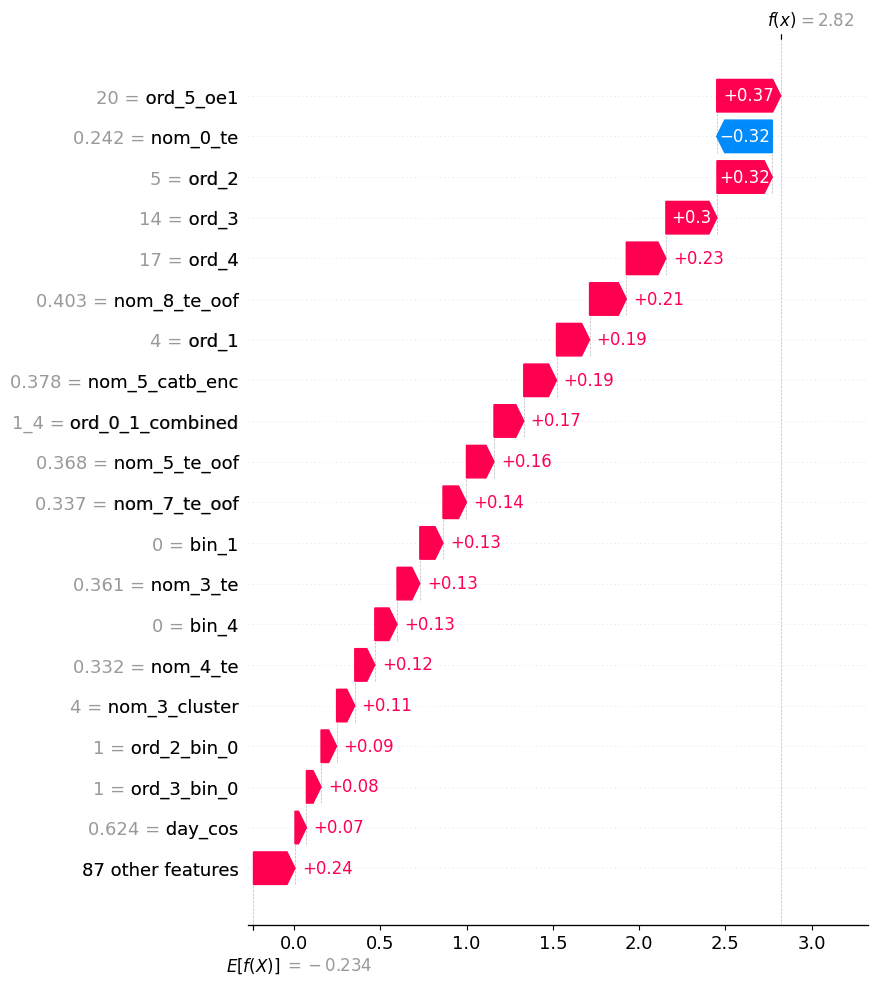

In [44]:
import pandas as pd
import numpy as np
import shap

# 1. Identify "Most Wrong" using integer positions
# We reset the index so 'index' becomes a column we can use to look up oof_preds
error_df = pd.DataFrame({
    'true_label': y_train_numeric,
    'pred_prob': oof_preds if cfg.TASK.lower() == "binary" else list(oof_preds)
}, index=X_train.index)

if cfg.TASK.lower() == "binary":
    error_df['error_magnitude'] = np.abs(error_df['true_label'] - error_df['pred_prob'])
else:
    # Multiclass logic: Prob assigned to the correct class
    probs_array = np.array(error_df['pred_prob'].tolist())
    correct_class_probs = probs_array[np.arange(len(y_train_numeric)), y_train_numeric]
    error_df['error_magnitude'] = 1 - correct_class_probs

# 2. Get the integer POSITION of the most wrong row
# We use .argsort() to find the position in the oof_preds array
most_wrong_positions = error_df['error_magnitude'].argsort()[::-1]
top_wrong_pos = most_wrong_positions.iloc[0] 

# 3. Get the original Index Label for X_train
wrong_label = X_train.index[top_wrong_pos]
row_to_explain = X_train.iloc[[top_wrong_pos]]

# 4. Analysis & Plotting
if cfg.TASK.lower() == "binary":
    predicted_val = 1 if oof_preds[top_wrong_pos] > 0.5 else 0
    conf = oof_preds[top_wrong_pos] if predicted_val == 1 else 1 - oof_preds[top_wrong_pos]
else:
    predicted_val = np.argmax(oof_preds[top_wrong_pos])
    conf = np.max(oof_preds[top_wrong_pos])

print(f"--- Error Analysis: Position {top_wrong_pos} (Label {wrong_label}) ---")
print(f"Actual: {y_train_numeric[top_wrong_pos]} | Predicted: {predicted_val} ({conf:.2%} confidence)")

# SHAP Waterfall
explainer = shap.Explainer(final_model)
shap_values_wrong = explainer(row_to_explain)

if len(shap_values_wrong.shape) == 3:
    shap.plots.waterfall(shap_values_wrong[0, :, int(predicted_val)], max_display=20)
else:
    shap.plots.waterfall(shap_values_wrong[0], max_display=20)

In [45]:
# Filter your interaction_df to see what pairs with ord_1
ord_1_interactions = interaction_df[
    (interaction_df['feature1'] == 'ord_5_oe1') | 
    (interaction_df['feature2'] == 'ord_5_oe1')
]
print("Top interactions for ord_5_oe1:")
print(ord_1_interactions.head(5))

Top interactions for ord_5_oe1:
      feature1     feature2  importance
8        ord_2    ord_5_oe1    0.931372
25       bin_4    ord_5_oe1    0.604664
36   ord_5_oe1  _hash_enc48    0.487130
122  ord_5_oe1     nom_0_te    0.248535
151      ord_3    ord_5_oe1    0.198110


In [46]:
# Create the interaction feature
def apply_ord_interaction(df):
    # We combine ord_0 and ord_1 into a single unique identifier
    # Example: ord_0=3 and ord_1=4 becomes "3.0_4.0"
    df['ord_5_oe1_ord_2_combined'] = df['ord_2'].astype(str) + "_" + df['ord_5_oe1'].astype(str)
    return df

X_train = apply_ord_interaction(X_train)
X_test = apply_ord_interaction(X_test)

# Update cat_features so CatBoost treats this new string column correctly
if 'ord_5_oe1_ord_2_combined' not in cat_features:
    cat_features.append('ord_5_oe1_ord_2_combined')

print("New feature 'ord_5_oe1_ord_2_combined' added to X_train and cat_features.")

New feature 'ord_5_oe1_ord_2_combined' added to X_train and cat_features.


In [47]:
X_train['ord_5_oe1_ord_2_combined']

101940    2_26.0
194040    5_15.0
163352    2_36.0
149687    4_46.0
198525    0_52.0
           ...  
38011     1_46.0
112442     0_1.0
220649    5_15.0
107868    0_11.0
103459    3_46.0
Name: ord_5_oe1_ord_2_combined, Length: 15000, dtype: object

In [54]:
cat_features = ['ord_5_oe1_ord_2_combined', 'ord_0_1_combined']